# Robust Control of an Inverted Double Pendulum

*Author: Hans Olischläger*

Two-stage workflow combining amortized inference with model predictive control (MPC).

1. **Identification.** A double pendulum swings freely from near-horizontal under gravity.
   We observe the two joint angles over time and infer the rod masses $m_1, m_2$ with a
   BayesFlow posterior approximator.
2. **Robust control.** The same pendulum is mounted on a cart, hanging down, and must be
   swung up and balanced. The controller does not know the true masses, so it optimises
   over a *scenario tree* built from the posterior instead of a single point estimate.

The posterior therefore does more than quantify uncertainty: it defines the set of models
the controller has to succeed against.

The MPC machinery lives in `dp_control_helper.py` next to this notebook and requires
[do-mpc](https://www.do-mpc.com/), a nice library for model predictive control based on [CasADi](https://web.casadi.org/):

```
pip install do-mpc
```

The control implementation is adapted from the do-mpc example gallery:
<https://www.do-mpc.com/en/latest/example_gallery/DIP.html>

## Setup

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras
import matplotlib.pyplot as plt
import numpy as np
import scipy

import bayesflow as bf
import dp_control_helper as ctrl

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
/home/ho/.venvs/dp-control/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ho/.venvs/dp-control/lib/python3.13/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/ho/.venvs/dp-control/lib/python3.13/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('Th

## The identification problem

The free-swinging pendulum is an ODE system with no closed-form likelihood, integrated with
RK4. Rod lengths, masses, gravity and the two initial angles are drawn from the prior; only
the angle trajectories are observed.

In [2]:
def bounded_normal(mean, std, low=-np.inf, high=np.inf):
    """Normal(mean, std) truncated to [low, high], bounds in original units."""
    a = (low - mean) / std
    b = (high - mean) / std
    return scipy.stats.truncnorm(a=a, b=b, loc=mean, scale=std)


PRIOR = {
    "g": bounded_normal(mean=9.81, std=0.01, low=0),
    "l1": bounded_normal(mean=1.0, std=0.1, low=0),
    "l2": bounded_normal(mean=1.0, std=0.1, low=0),
    "m1": bounded_normal(mean=1.0, std=0.1, low=0),
    "m2": bounded_normal(mean=1.0, std=0.1, low=0),
    "theta1": scipy.stats.vonmises(kappa=100.0, loc=np.pi / 2),
    "theta2": scipy.stats.vonmises(kappa=100.0, loc=np.pi / 2),
}


def prior(batch_shape):
    n = batch_shape[0]
    return {k: rv.rvs(size=(n, 1)).astype("float32") for k, rv in PRIOR.items()}

In [3]:
T = 10.0
DT = 0.05
NUM_STEPS = int(T / DT)


def observation_model(batch_shape, g, l1, l2, m1, m2, theta1, theta2):
    """Integrate the free double pendulum with RK4 and return both angle trajectories."""
    g, l1, l2, m1, m2 = (np.asarray(v, dtype=np.float64)[..., 0] for v in (g, l1, l2, m1, m2))

    # coefficients of the Euler-Lagrange equations
    h4 = l1**2 * (m1 / 3.0 + m2)
    h5 = m2 * l1 * l2 / 2.0
    h6 = m2 * l2**2 / 3.0
    h7 = l1 * g * (m1 / 2.0 + m2)
    h8 = m2 * g * l2 / 2.0

    def derivs(y):
        ph1, w1, ph2, w2 = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
        delta = ph1 - ph2
        cos_d, sin_d = np.cos(delta), np.sin(delta)
        det = h4 * h6 - h5**2 * cos_d**2
        rhs1 = -h7 * np.sin(ph1) - h5 * w2**2 * sin_d
        rhs2 = h5 * w1**2 * sin_d - h8 * np.sin(ph2)
        dydt = np.empty_like(y)
        dydt[:, 0] = w1
        dydt[:, 1] = (h6 * rhs1 - h5 * cos_d * rhs2) / det
        dydt[:, 2] = w2
        dydt[:, 3] = (h4 * rhs2 - h5 * cos_d * rhs1) / det
        return dydt

    n = batch_shape[0]
    y = np.zeros((n, 4))
    y[:, 0] = np.asarray(theta1, dtype=np.float64)[..., 0]
    y[:, 2] = np.asarray(theta2, dtype=np.float64)[..., 0]

    theta1_traj = np.empty((n, NUM_STEPS))
    theta2_traj = np.empty((n, NUM_STEPS))
    theta1_traj[:, 0], theta2_traj[:, 0] = y[:, 0], y[:, 2]

    for i in range(1, NUM_STEPS):
        k1 = derivs(y)
        k2 = derivs(y + 0.5 * DT * k1)
        k3 = derivs(y + 0.5 * DT * k2)
        k4 = derivs(y + DT * k3)
        y = y + (DT / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        theta1_traj[:, i], theta2_traj[:, i] = y[:, 0], y[:, 2]

    return {
        "theta1_traj": theta1_traj[..., None].astype("float32"),
        "theta2_traj": theta2_traj[..., None].astype("float32"),
    }

In [4]:
simulator = bf.make_simulator(
  [prior, observation_model],
  obj_kwargs={
      "prior": {"is_batched": True},
      "observation_model": {"is_batched": True},
  },
)

sims = simulator.sample(4)
keras.tree.map_structure(keras.ops.shape, sims)

{'g': (4, 1),
 'l1': (4, 1),
 'l2': (4, 1),
 'm1': (4, 1),
 'm2': (4, 1),
 'theta1': (4, 1),
 'theta2': (4, 1),
 'theta1_traj': (4, 200, 1),
 'theta2_traj': (4, 200, 1)}

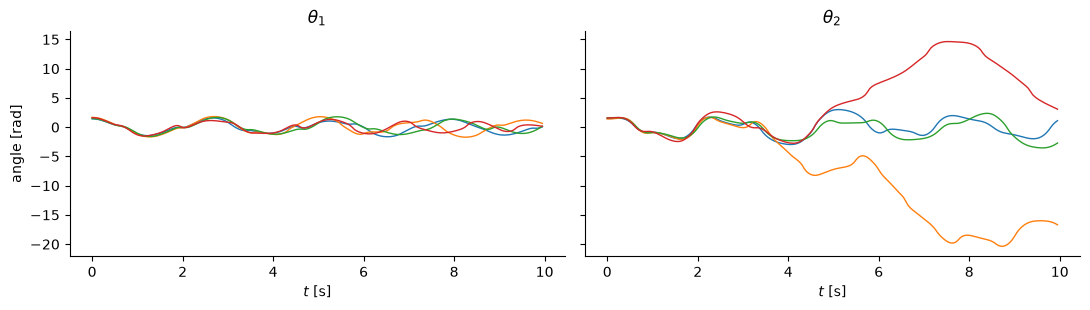

In [5]:
t = np.arange(NUM_STEPS) * DT
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, key, name in zip(axes, ["theta1_traj", "theta2_traj"], [r"$\theta_1$", r"$\theta_2$"]):
    ax.plot(t, sims[key][..., 0].T, lw=1)
    ax.set_xlabel("$t$ [s]")
    ax.set_title(name)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("angle [rad]")
fig.tight_layout()

## Amortized posterior over the rod masses

The trajectories are subsampled to every fifth step before they reach the summary network,
and only $m_1, m_2$ are inferred — the remaining parameters are treated as known at control
time.

In [6]:
adapter = (
    bf.Adapter()
    .to_array()
    .convert_dtype("float32", "float64")
    .concatenate(["theta1_traj", "theta2_traj"], into="summary_variables")
    .take("summary_variables", indices=np.arange(0, NUM_STEPS, 5), axis=-2)
    .concatenate(["m1", "m2"], into="inference_variables")
    .drop(["g", "l1", "l2", "theta1", "theta2"])
)
adapter

Adapter([0: ToArray -> 1: ConvertDType -> 2: Concatenate(['theta1_traj', 'theta2_traj'] -> 'summary_variables') -> 3: Take(include=['summary_variables']) -> 4: Concatenate(['m1', 'm2'] -> 'inference_variables') -> 5: Drop(['g', 'l1', 'l2', 'theta1', 'theta2'])])

In [7]:
NUM_TRAINING_SIMS = 5000

training_data = simulator.sample(NUM_TRAINING_SIMS)
validation_data = simulator.sample(200)

In [8]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(),
    summary_network="time_series_network",
)

history = workflow.fit_offline(
    training_data,
    epochs=20,
    batch_size=64,
    validation_data=validation_data,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
/home/ho/.venvs/dp-control/lib/python3.13/site-packages/keras/src/backend/jax/core.py:401: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray(x, dtype=dtype)


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 2.8113 - val_loss: 2.7770
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 2.6664 - val_loss: 2.5335
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 2.3803 - val_loss: 2.3405
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 1.9439 - val_loss: 1.7395
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 1.7049 - val_loss: 1.5462
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 1.5437 - val_loss: 1.4775
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 1.4769 - val_loss: 1.3731
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 1.3930 - val_loss: 1.3177
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 1.2894 - val_loss: 1.2234
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 1.2140 - val_loss: 1.0166
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 1.1486 - val_loss: 1.1757
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 1

INFO:bayesflow:Training completed in 1.85 minutes.


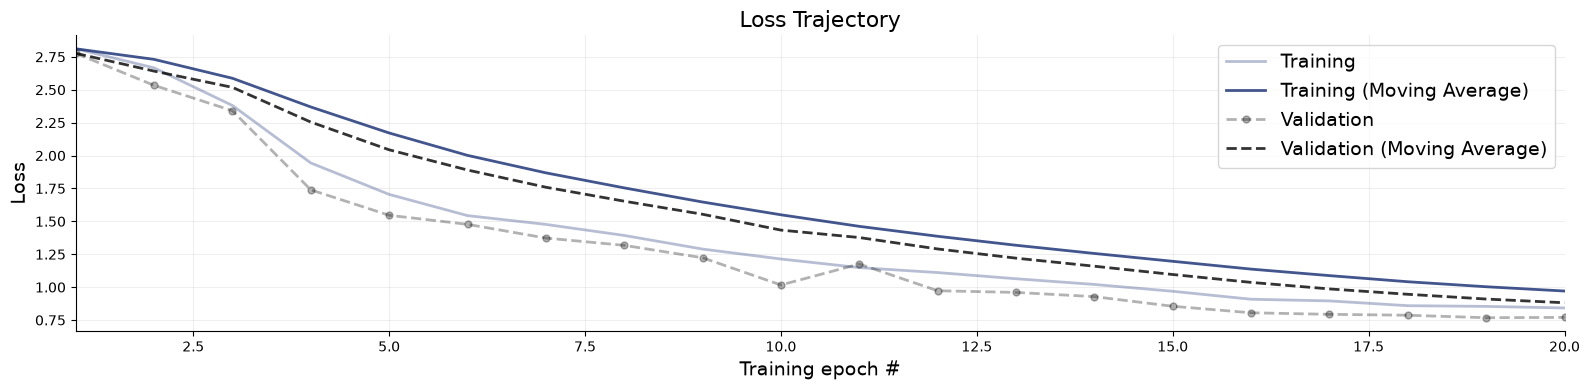

In [9]:
f = bf.diagnostics.plots.loss(history)

## Posterior for a single observation

Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.00s/batch]


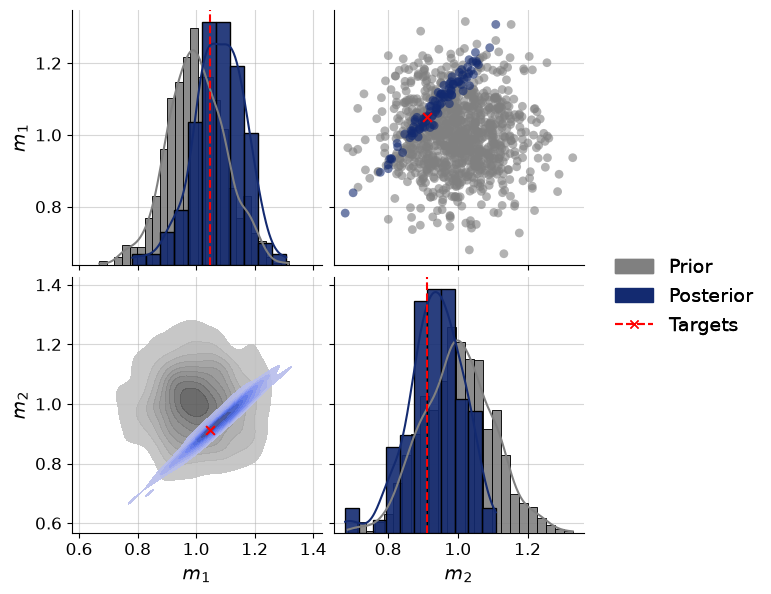

In [10]:
NUM_POSTERIOR_SAMPLES = 100

observation = simulator.sample(1)
posterior_samples = workflow.approximator.sample(
    conditions=observation, num_samples=NUM_POSTERIOR_SAMPLES
)
prior_samples = prior((1000,))

f = bf.diagnostics.plots.pairs_posterior(
    posterior_samples,
    targets=observation,
    priors=prior_samples,
    dataset_id=0,
    variable_keys=["m1", "m2"],
    variable_names=["$m_1$", "$m_2$"],
)

## Robust swing-up

The controller is built for the *true* geometry and gravity, which we assume known, but the
masses come from the posterior. `pick_scenarios` reduces the posterior draws to `k`
representative $(m_1, m_2)$ pairs by k-means; do-mpc then branches its prediction tree over
those scenarios and optimises the worst case, rather than trusting a point estimate.

`n_robust=1` means one branching level. Raising it makes the controller more conservative
and the optimisation considerably more expensive.

In [16]:
M0 = 0.6  # cart mass [kg]
X0 = np.array([0.0, 0.99 * np.pi, 0.99 * np.pi, 0.0, 0.0, 0.0])  # hanging down, at rest

MPC_KWARGS = dict(
    n_horizon=100,
    n_robust=1,
    t_step=0.04,
    w_F=0.1,
    F_max=100,
    x_bound=1.3,
)

g_true = float(observation["g"][0, 0])
l1_true = float(observation["l1"][0, 0])
l2_true = float(observation["l2"][0, 0])
m1_true = float(observation["m1"][0, 0])
m2_true = float(observation["m2"][0, 0])

scenarios = ctrl.pick_scenarios({k: posterior_samples[k][0] for k in ("m1", "m2")}, 3)
print("scenario masses (m1, m2):\n", scenarios)
print(f"true masses: ({m1_true:.3f}, {m2_true:.3f})")

scenario masses (m1, m2):
 [[1.0416876  0.90613097]
 [1.1524822  1.0023546 ]
 [0.9121809  0.78849363]]
true masses: (1.049, 0.912)


In [17]:
model = ctrl.build_model(M0, l1_true, l2_true, g_true)
mpc = ctrl.build_mpc(model, scenarios, **MPC_KWARGS)
sim = ctrl.build_simulator(model, m1_true, m2_true, t_step=MPC_KWARGS["t_step"])
est = ctrl.build_estimator(model)

result = ctrl.run_closed_loop(mpc, sim, est, X0, n_steps=100)
print(f"completed {result['n_steps_completed']} steps | success={result['success']}")

/home/ho/.venvs/dp-control/lib/python3.13/site-packages/casadi/casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)
100%|██████████| 100/100 [01:43<00:00,  1.03s/it]


completed 100 steps | success=True


## Animation

The control optimization did not know the true values of pendulum it was acting on while planning. Instead, it took three representative scenarios from the posterior over the unknown masses into account (see the three planned lines in blue on the right).
It appears that BayesFlow's converged approximation identified the parameters with sufficient accuracy such that a stable solution of the swing-up was found and acted on successfully. 

In [24]:
ctrl.animate_with_predictions(result, l1_true, l2_true, skip=2)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1400x700 -pix_fmt rgba -framerate 12.5 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpio8uxn7g/temp.m4v


The animation above is an HTML5 video. If you are looking at a renderer that strips it, like GitHub's notebook
view, you can find a gif [here](control.gif).

In [27]:
ctrl.animate_with_predictions(result, l1_true, l2_true, skip=4, dpi=80, filename="control.gif")

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


![Robust swing-up of the inverted double pendulum](control.gif)